# Radio Modulation Classification using FFT and Deep Learning

**Dataset:** RadioML 2016.10a - 11 modulation types, 220,000 samples  
**Model:** 1D Convolutional Neural Network  
**Result:** 74.9% accuracy on signals with SNR >= 0 dB

---

Radio signals carry information by modulating a carrier wave - changing its amplitude, frequency, or phase in a controlled way.

Each modulation scheme leaves a distinct fingerprint in the frequency domain.

This project uses the Fourier transform to extract those fingerprints and trains a neural network to identify them.


**Pipeline:** Raw I/Q signal -> FFT magnitude spectrum -> 1D CNN -> modulation type

## 0. Setup

In [2]:
!pip install torch torchvision --quiet

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from numpy.fft import fft
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import kagglehub

## 1. Load the Dataset

RadioML 2016.10a is a synthetic dataset generated with GNU Radio by DeepSig.

It covers 11 modulation types at 20 SNR levels from -20 dB to +18 dB, with 1,000 signal samples per combination.

The data is stored as a dictionary.

Each key is a `(modulation, snr)` tuple and each value is a numpy array of shape `(1000, 2, 128)` - 1,000 samples, 2 channels (I and Q), 128 time steps.

In [4]:
path = kagglehub.dataset_download("nolasthitnotomorrow/radioml2016-deepsigcom")

with open(os.path.join(path, "RML2016.10a_dict.pkl"), "rb") as f:
    data = pickle.load(f, encoding="latin1")  # latin1 needed for Python 3 compatibility

keys = list(data.keys())
mods = sorted(set(k[0] for k in keys))
snrs = sorted(set(k[1] for k in keys))

print(f"Keys:         {len(keys)}  ({len(mods)} modulations x {len(snrs)} SNR levels)")
print(f"Modulations:  {mods}")
print(f"SNR levels:   {snrs}")
print(f"Sample shape: {data[keys[0]].shape}  -> (1000 samples, 2 channels, 128 time steps)")

Using Colab cache for faster access to the 'radioml2016-deepsigcom' dataset.
Keys:         220  (11 modulations x 20 SNR levels)
Modulations:  ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels:   [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Sample shape: (1000, 2, 128)  -> (1000 samples, 2 channels, 128 time steps)


## 2. Explore the Data

Each signal has two channels - I (in-phase) and Q (quadrature).

They are not two separate signals. Together they form one complex number `I + jQ`, which is the standard internal representation for all modern radio systems.

You need both channels to fully capture the modulation.

In [5]:
X, y, snr_list = [], [], []

for (mod, snr), samples in data.items():
    for s in samples:
        X.append(s)
        y.append(mod)
        snr_list.append(snr)

X        = np.array(X)         # (220000, 2, 128)
y        = np.array(y)         # (220000,)
snr_list = np.array(snr_list)  # (220000,)

print("X shape:       ", X.shape)
print("y shape:       ", y.shape)
print("snr_list shape:", snr_list.shape)

X shape:        (220000, 2, 128)
y shape:        (220000,)
snr_list shape: (220000,)


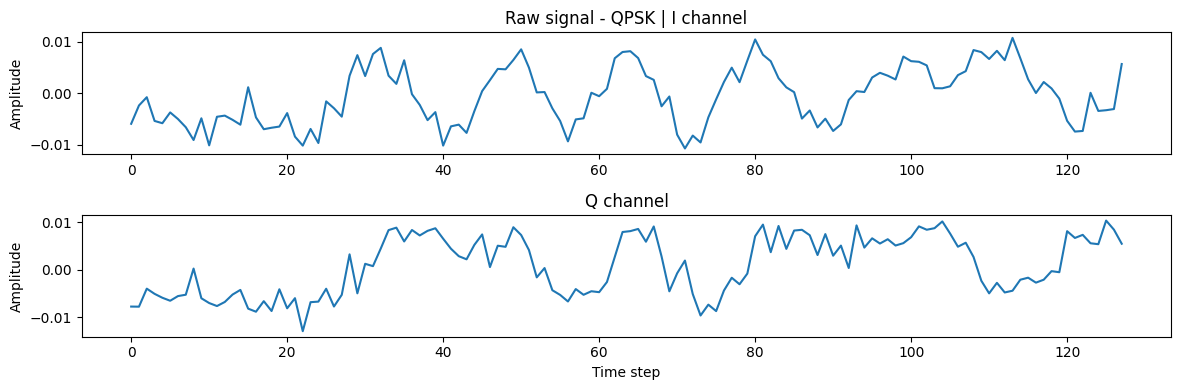

In [6]:
idx = 0
fig, axes = plt.subplots(2, 1, figsize=(12, 4))

axes[0].plot(X[idx, 0])
axes[0].set_title(f"Raw signal - {y[idx]} | I channel")
axes[0].set_ylabel("Amplitude")

axes[1].plot(X[idx, 1])
axes[1].set_title("Q channel")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time step")

plt.tight_layout()
plt.show()

## 3. FFT Feature Extraction

Raw time-domain signals are noisy and inconsistent - the same modulation looks different each time depending on channel effects and timing. The frequency domain is more stable and easier to classify from.

We convert each signal to a magnitude spectrum in three steps:

1. Combine I and Q into one complex signal: `I + jQ`
2. Apply the FFT to decompose it into frequency components
3. Take the magnitude - how much energy is at each frequency bin

The result is a 128-element vector.

In [7]:
def compute_fft_features(signal_iq):
    complex_signal = signal_iq[0] + 1j * signal_iq[1]  # combine I and Q into one complex signal
    fft_result     = fft(complex_signal)
    return np.abs(fft_result)                           # magnitude spectrum, shape (128,)

X_fft = np.array([compute_fft_features(s) for s in X])
print("FFT feature shape:", X_fft.shape)  # (220000, 128)

FFT feature shape: (220000, 128)


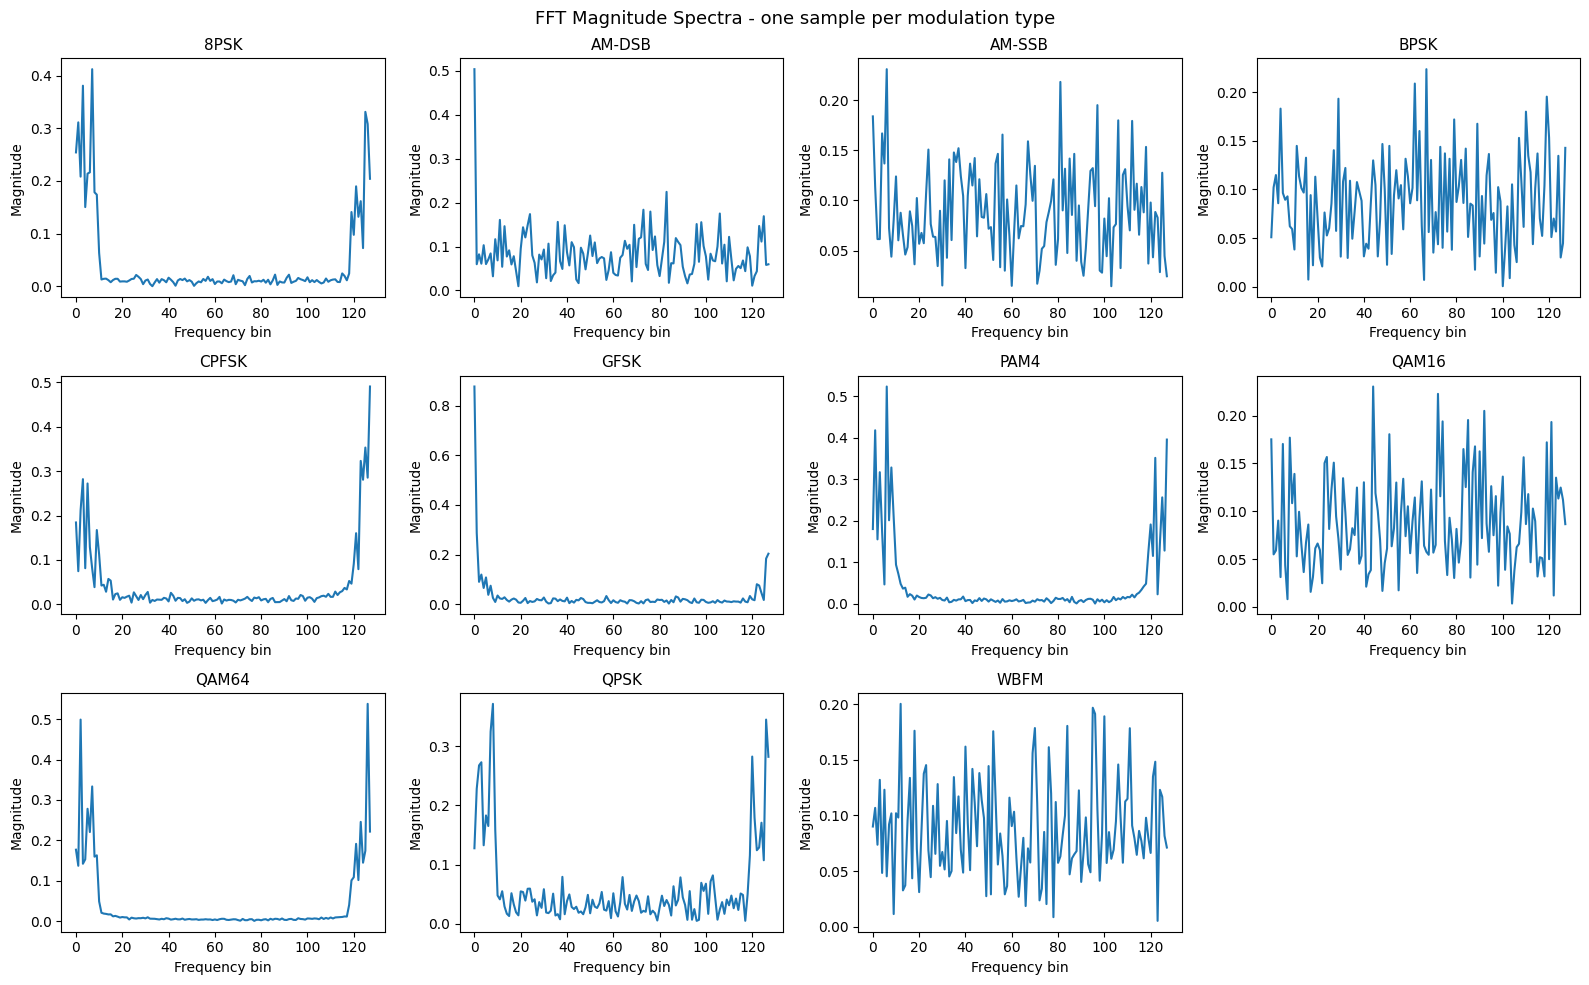

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, mod in enumerate(np.unique(y)):
    sample_idx = np.where(y == mod)[0][0]
    axes[i].plot(X_fft[sample_idx])
    axes[i].set_title(mod, fontsize=11)
    axes[i].set_xlabel("Frequency bin")
    axes[i].set_ylabel("Magnitude")

axes[-1].set_visible(False)  # hide the unused 12th subplot

plt.suptitle("FFT Magnitude Spectra - one sample per modulation type", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Prepare Data for Training

Four steps before training:

**SNR filtering** - We drop all samples with SNR below 0 dB. At very low SNR the signal is buried in noise and the modulation fingerprint is unrecognizable. Keeping those samples does not help the model learn anything useful.

**Label encoding** - PyTorch needs integer class labels, not strings. We map each modulation name to a number (0-10) and keep the encoder to reverse predictions back to names later.

**Train / val / test split** - 70% training, 15% validation, 15% test. Stratified by class so every split has a balanced mix of all 11 modulations.

**Normalization** - Features are normalized to zero mean and unit variance. The mean and standard deviation are computed on the training set only and then applied to all splits - this prevents any information from the test set leaking into training.

In [9]:
high_snr_mask = snr_list >= 0

X_fft_clean = X_fft[high_snr_mask]
y_clean     = y[high_snr_mask]
snr_clean   = snr_list[high_snr_mask]

print(f"Before filter: {X_fft.shape[0]:,} samples  (all SNR levels)")
print(f"After filter:  {X_fft_clean.shape[0]:,} samples  (SNR >= 0 dB only)")

Before filter: 220,000 samples  (all SNR levels)
After filter:  110,000 samples  (SNR >= 0 dB only)


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_clean)

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}  ->  {cls}")

Class mapping:
  0  ->  8PSK
  1  ->  AM-DSB
  2  ->  AM-SSB
  3  ->  BPSK
  4  ->  CPFSK
  5  ->  GFSK
  6  ->  PAM4
  7  ->  QAM16
  8  ->  QAM64
  9  ->  QPSK
  10  ->  WBFM


In [11]:
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_fft_clean, y_encoded, snr_clean,
    test_size=0.3, random_state=42, stratify=y_encoded  # stratify keeps class balance across splits
)
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8  # small offset avoids division by zero

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

Train: 77,000  |  Val: 16,500  |  Test: 16,500


In [12]:
class RadioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(RadioDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(RadioDataset(X_val,   y_val),   batch_size=256, shuffle=False)
test_loader  = DataLoader(RadioDataset(X_test,  y_test),  batch_size=256, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 301  |  Val batches: 65  |  Test batches: 65


## 5. Model Architecture

We use a 1D convolutional neural network (CNN).

A dense network treats every frequency bin as independent - it has no concept that bin 40 and bin 41 are neighbours. That is not ideal for spectral data where a peak spans several adjacent bins. A CNN slides a small window across the 128-point spectrum and learns to detect local patterns, which is a much better fit.

**Architecture:**
- Three conv blocks: `Conv1d -> BatchNorm -> ReLU -> MaxPool`
- MaxPool halves the length at each stage: 128 -> 64 -> 32 -> 16
- A dense classifier at the end maps to 11 output scores, one per modulation

`BatchNorm` keeps activations stable during training. `Dropout(0.4)` prevents the model from over-relying on any single feature.

In [13]:
class RadioClassifier(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),    # 128 -> 64

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),    # 64 -> 32

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),    # 32 -> 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)   # (batch, 128) -> (batch, 1, 128): add channel dim for Conv1d
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = RadioClassifier().to(device)
print(model)

Device: cuda
RadioClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dr

## 6. Training

20 epochs, batches of 256 samples.

- **Loss:** CrossEntropyLoss - standard for multi-class problems
- **Optimizer:** Adam, learning rate 1e-3
- **Scheduler:** halves the learning rate every 5 epochs, which helps fine-tuning as the model converges

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct = 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        with torch.set_grad_enabled(train):
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS}  |  "
          f"train loss {train_loss:.4f}  acc {train_acc:.4f}  |  "
          f"val loss {val_loss:.4f}  acc {val_acc:.4f}")

Epoch 01/20  |  train loss 1.0581  acc 0.5490  |  val loss 0.8737  acc 0.6166
Epoch 02/20  |  train loss 0.8655  acc 0.6175  |  val loss 0.7529  acc 0.6639
Epoch 03/20  |  train loss 0.7972  acc 0.6415  |  val loss 0.7387  acc 0.6716
Epoch 04/20  |  train loss 0.7448  acc 0.6621  |  val loss 0.6708  acc 0.7036
Epoch 05/20  |  train loss 0.7121  acc 0.6755  |  val loss 0.6605  acc 0.7050
Epoch 06/20  |  train loss 0.6347  acc 0.7062  |  val loss 0.5914  acc 0.7256
Epoch 07/20  |  train loss 0.6086  acc 0.7169  |  val loss 0.6387  acc 0.7071
Epoch 08/20  |  train loss 0.5884  acc 0.7242  |  val loss 0.5885  acc 0.7202
Epoch 09/20  |  train loss 0.5754  acc 0.7286  |  val loss 0.5625  acc 0.7361
Epoch 10/20  |  train loss 0.5569  acc 0.7355  |  val loss 0.5674  acc 0.7288
Epoch 11/20  |  train loss 0.5245  acc 0.7481  |  val loss 0.5489  acc 0.7385
Epoch 12/20  |  train loss 0.5186  acc 0.7515  |  val loss 0.5400  acc 0.7438
Epoch 13/20  |  train loss 0.5094  acc 0.7553  |  val loss 0.532

## 7. Results

Overall test accuracy is **74.9%** on SNR >= 0 dB signals.

Spectrally distinct modulations - CPFSK, GFSK, AM-SSB, PAM4 - all score above 97% F1. The two main failure points are QPSK vs 8PSK and QAM16 vs QAM64.

These pairs have nearly identical magnitude spectra and differ primarily in phase - information that FFT magnitude discards by design. This is a feature limitation, not a model problem. The confusion matrix below makes the failure pattern clear.

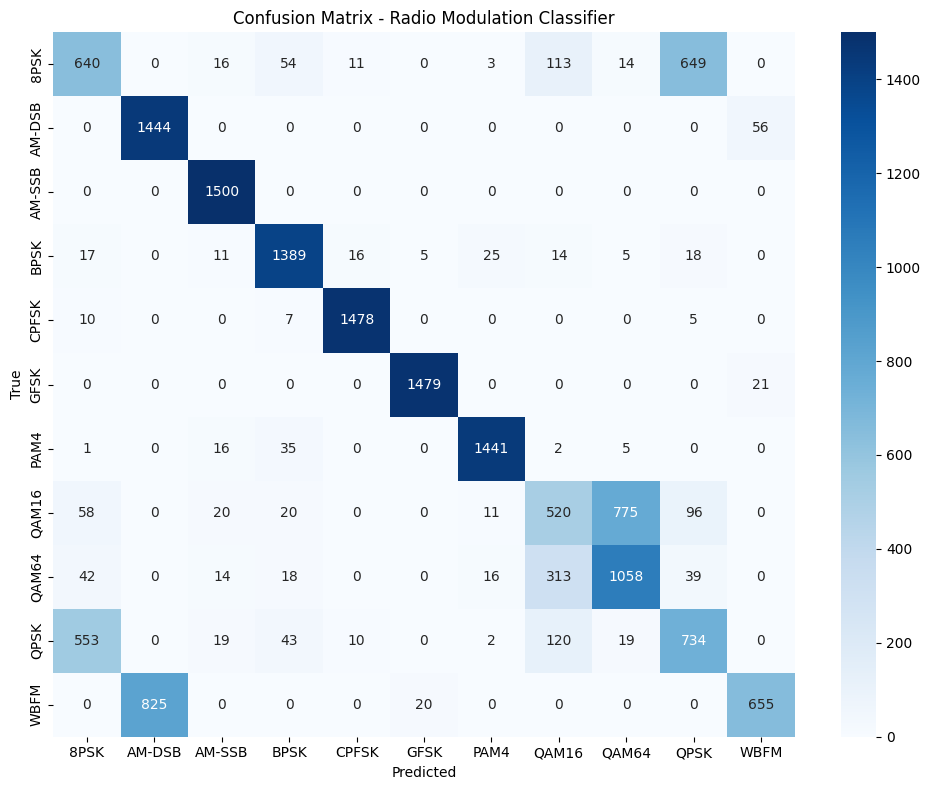

              precision    recall  f1-score   support

        8PSK       0.48      0.43      0.45      1500
      AM-DSB       0.64      0.96      0.77      1500
      AM-SSB       0.94      1.00      0.97      1500
        BPSK       0.89      0.93      0.91      1500
       CPFSK       0.98      0.99      0.98      1500
        GFSK       0.98      0.99      0.98      1500
        PAM4       0.96      0.96      0.96      1500
       QAM16       0.48      0.35      0.40      1500
       QAM64       0.56      0.71      0.63      1500
        QPSK       0.48      0.49      0.48      1500
        WBFM       0.89      0.44      0.59      1500

    accuracy                           0.75     16500
   macro avg       0.75      0.75      0.74     16500
weighted avg       0.75      0.75      0.74     16500



In [15]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Radio Modulation Classifier")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=le.classes_))

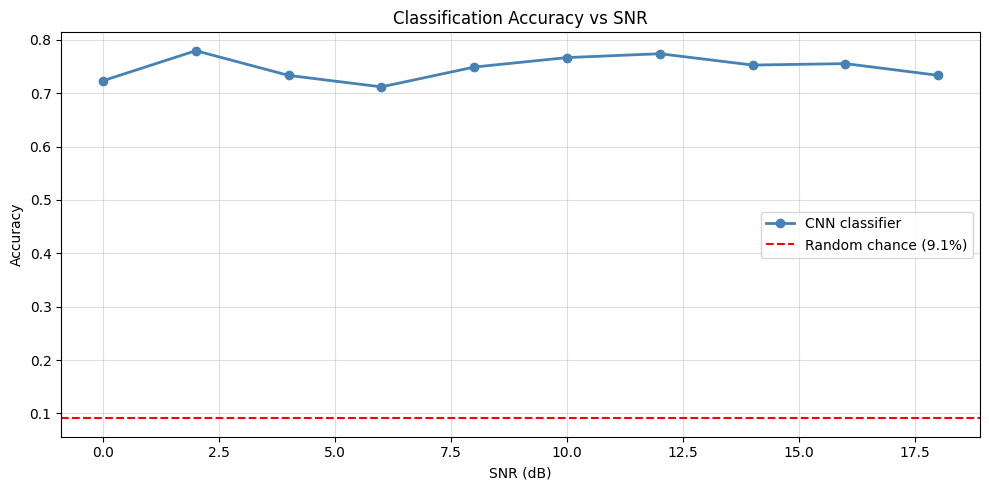

In [16]:
snr_accuracies = {}

with torch.no_grad():
    for snr in sorted(np.unique(snr_test)):
        mask  = snr_test == snr
        X_snr = torch.tensor(X_test[mask], dtype=torch.float32).to(device)
        y_snr = torch.tensor(y_test[mask],  dtype=torch.long).to(device)
        preds = model(X_snr).argmax(1)
        snr_accuracies[snr] = (preds == y_snr).float().mean().item()

plt.figure(figsize=(10, 5))
plt.plot(list(snr_accuracies.keys()), list(snr_accuracies.values()),
         marker="o", linewidth=2, color="steelblue", label="CNN classifier")
plt.axhline(y=1/11, color="r", linestyle="--", label="Random chance (9.1%)")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy vs SNR")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [17]:
print(f"Overall test accuracy: {(all_preds == all_labels).mean()*100:.2f}%")
print()
print(f"{'SNR (dB)':<12} {'Accuracy':>10}")
print("-" * 24)
for snr, acc in sorted(snr_accuracies.items()):
    print(f"{snr:<12} {acc*100:>9.1f}%")

Overall test accuracy: 74.78%

SNR (dB)       Accuracy
------------------------
0                 72.3%
2                 78.0%
4                 73.3%
6                 71.2%
8                 74.9%
10                76.7%
12                77.4%
14                75.3%
16                75.5%
18                73.3%
